In [4]:
# work with jl2815 environment
import xarray as xr # for netCDF4 
import pandas as pd
import numpy as np
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import os
# Ignore warnings due to duplicated dimension names
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="xarray")
from pathlib import Path

import sys
gems_tco_path = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
sys.path.append(gems_tco_path)

from GEMS_TCO import configuration as config
from GEMS_TCO import data_preprocess as dmbh

In [5]:
file_path = "/Volumes/Backup Plus/GEMS_UNZIPPED/2024070131/20240701_0045.nc"  # portable device
file_path = "/Volumes/Backup Plus/GEMS_UNZIPPED/2023070131/20230701_0045.nc"  # portable device
file_path = "/Volumes/Backup Plus/GEMS_UNZIPPED/2022070131/20220701_0045.nc"  # portable device


#file_path = "/Users/joonwonlee/Documents/GEMS_DATA/2024070131/20240701_0045.nc" # mac
location = xr.open_dataset(file_path, group='Geolocation Fields')
Z = xr.open_dataset(file_path, group='Data Fields')

import netCDF4 as nc

dataset = nc.Dataset(file_path)

# Print all group names
print("Groups in the NetCDF file:")
for group_name in dataset.groups:
    print(group_name)

# Optionally, print variables in each group
for group_name, group in dataset.groups.items():
    print(f"\nVariables in group '{group_name}':")
    for var_name in group.variables:
        print(var_name)

# Close the dataset
dataset.close()

Groups in the NetCDF file:
Data Fields
Geolocation Fields
METADATA

Variables in group 'Data Fields':
AveragingKernel
CloudPressure
ColumnAmountO3
DegreesOfFreedomForSignal
EstimatedError
FinalAlgorithmFlags
LayerEfficiency
Nvalue
O3BelowCloud
Reflectivity340
Reflectivity380
Residue
StepOneO3
StepTwoO3
TerrainPressure
dNdR
dR_dl
EffectiveCloudFraction

Variables in group 'Geolocation Fields':
Latitude
Longitude
RelativeAzimuthAngle
SolarZenithAngle
ViewingZenithAngle
Time
GroundPixelQualityFlags

Variables in group 'METADATA':


In [11]:
computer_path = config.mac_data_load_path  # mac
print(f'computer_path: {computer_path}')

portable_disk_path = "/Volumes/Backup Plus/GEMS_UNZIPPED/" 
print(f'portable disk path: {portable_disk_path}')
year = 2025
month = 7
#filelist_instance = dmbh.file_path_list(year, month, computer_path)

filelist_instance = dmbh.file_path_list(year, month, portable_disk_path)

# for July 2023, and 2025 use the same code below
file_paths_list = filelist_instance.file_names_july24() 

# Case 1: Broad area
instance = dmbh.MonthAggregatedCSV(-3, 2, 121, 131)

instance = dmbh.MonthAggregatedCSV(-3, 7, 111, 131)

GoodQualityData = instance.aggregate_july24tocsv(file_paths_list)
instance.save(GoodQualityData, year, month, computer_path)

computer_path: /Users/joonwonlee/Documents/GEMS_DATA/
portable disk path: /Volumes/Backup Plus/GEMS_UNZIPPED/


137140.50403225806


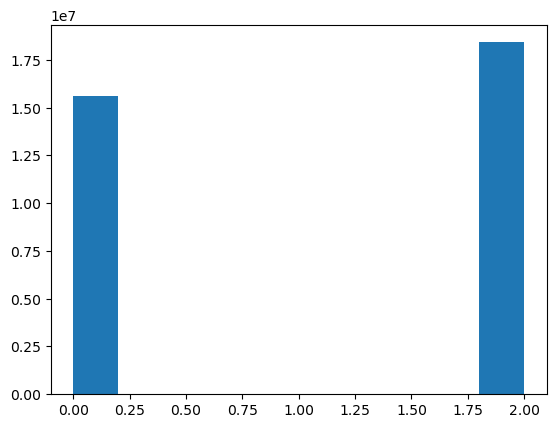

In [7]:
# Check shape ratio
print(GoodQualityData.shape[0]/31/8)
# 5 10 123 133  33856 without filtering 0 only: 10759  fine list: 32063 
# 0 5 123 133 00 only  13520  33092 if 0|2|4|128
# 0 2 filtering: 
plt.hist(GoodQualityData['FinalAlgorithmFlags'])
plt.show()

In [8]:
print( year, month)

instance.save(GoodQualityData, year, month, computer_path)


2024 7


Below is the loop for processing multiple months for csv files. you can skip this chunk

In [ ]:

# ── Multi-month batch: nc → CSV ───────────────────────────────────────────────
# Already processed: 2022/07, 2024/07, 2025/07 → skip those
# Add or remove (year, month) tuples as needed

TARGETS = [
    # 2022
    (2022, 5), (2022, 6), (2022, 8), (2022, 9),
    # 2023 (전체)
    (2023, 1), (2023, 2), (2023, 3), (2023, 4), (2023, 5), (2023, 6),
    (2023, 7), (2023, 8), (2023, 9), (2023, 10), (2023, 11), (2023, 12),
    # 2024
    (2024, 1), (2024, 2), (2024, 3), (2024, 4), (2024, 5), (2024, 6),
    (2024, 8), (2024, 9), (2024, 10), (2024, 11), (2024, 12),
    # 2025
    (2025, 4), (2025, 5), (2025, 6), (2025, 8), (2025, 9),
]


portable_disk = "/Volumes/Backup Plus/Gems_unzipped/"
computer_path = config.mac_data_load_path

for year, month in TARGETS:
    print(f"\n{'='*50}")
    print(f"  Processing {year}-{month:02d}")
    print(f"{'='*50}")
    try:
        filelist_instance = dmbh.file_path_list(year, month, portable_disk)
        file_paths_list   = filelist_instance.file_names_july24()

        # Default/narrow historical domain was (-3, 2, 121, 131).
        # Use expanded bounds when creating expanded CSV files.
        instance        = dmbh.MonthAggregatedCSV(-3, 7, 111, 131)
        GoodQualityData = instance.aggregate_july24tocsv(file_paths_list)

        instance.save(GoodQualityData, year, month, computer_path)
        print(f"  [Saved] CSV for {year}-{month:02d}  ({len(GoodQualityData)} rows)")
    except Exception as e:
        print(f"  [Error] {year}-{month:02d}: {e}")



  Processing 2022-04
  [Saved] CSV for 2022-04  (8515260 rows)


Now save pickle. Before you do this, you have to transfer csv file created above to the right folder eg. folder to data_2023

In [ ]:

# ── Expanded July CSV → bounds-aware orbit_map pickle ─────────────────────────
# Use the script below instead of MonthAggregatedHashmap(-3, 2, 121, 131),
# which created narrow orbit_mapYY_07.pkl files and caused expanded grids
# with finite values only in [-3,2] x [121,131].

!/opt/anaconda3/envs/faiss_env/bin/python step2_truncate_cvs_pickle_by_monthyear_020226.py \
    --years 2022 2023 2024 2025 \
    --months 7 \
    --bounds=-3,7,111,131 \
    --make-orbit-map \
    --overwrite



  orbit_map pickle: 2022-04
Reading file: /Users/joonwonlee/Documents/GEMS_DATA/data_2022/data_22_04_0130_N-32_E121131.csv
Successfully processed and saved data for year 22 month 04.
